# Constrained sampling on the ball with $J_s(x)=s\,[x]_\times$

The skew field is the one specified:

$$J_s(x)=\begin{pmatrix}0&-s x_3& s x_2\\ s x_3&0&-s x_1\\ -s x_2& s x_1&0\end{pmatrix},
\qquad\text{equivalently}\qquad J_s(x)\,w=s\,(x\times w),$$

on $K=\{x\in\mathbb R^3:\lVert x\rVert_2\le R\}$ with $R=1$, $\pi\propto e^{-U}\mathbf 1_K$, comparing
$J=0$ against $s=4,8,16$ on two targets. At this radius both targets **fill** $K$ — the truncation is
severe enough that mass reaches the wall rather than sitting in a core with a gap around it, which is
checked quantitatively below.

## What this field gives you for free

Three properties, all verified numerically below rather than asserted:

1. **Antisymmetric** by inspection, exactly.
2. **Tangential at the wall**: $J_s(x)\nu(x)=s\,(x\times x)/\lVert x\rVert=0$ *identically*, not just to
   leading order. This is the condition a projected scheme needs — the skew drift must add no normal
   component at $\partial K$, or the projection absorbs flux and the stationary law is wrong by an amount
   no stepsize refinement removes.
3. **Divergence-free, exactly.** Writing $(J_s)_{ik}=s\,\varepsilon_{ijk}x_j$ gives
   $\partial_k (J_s)_{ik}=s\,\varepsilon_{ijk}\delta_{jk}=0$.

Property 3 is the one that changes the code. The general state-dependent anchored dynamics carries a
correction term,

$$dX=e^{\Delta}\bigl[-(I+J(X))\nabla U_0+\nabla\!\cdot J(X)\bigr]dt+\sqrt2\,e^{\Delta/2}dW,$$

and a field built to aim its rotation plane at a fixed subspace does **not** kill it — for the plane-aimed
family $J(x)=\tfrac{s}{R^2}(\lVert x\rVert^2A+(Ax)x^\top-x(Ax)^\top)$ one has
$\nabla\!\cdot J=-\tfrac{s}{R^2}(d-2)Ax\ne0$, so the correction has to be computed and carried at every
step. For $J_s=s[x]_\times$ it vanishes identically, so the implemented update is just

$$x\ \leftarrow\ \Pi_K\Bigl(x-\eta\,e^{\Delta}\bigl(I+J_s(x)\bigr)\nabla U_0+\sqrt{2\eta}\,e^{\Delta/2}\xi\Bigr),$$

with no extra gradient and nothing to get wrong.

## What it costs you

The rotation plane at $x$ is $x^\perp$ — fixed by position, not a free parameter. There is no way to aim
this field at the target's slow directions; the only knob is $s$. And since
$\lVert J_s(x)\rVert_2=s\lVert x\rVert$, the field **vanishes at the origin** and is strongest at the wall.
Both facts are measured below, and they are why $s$ eventually stops buying speed and starts costing
accuracy.

In [1]:
%matplotlib inline
import math, os, time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from matplotlib.patches import Circle
from scipy.stats import ks_2samp, wasserstein_distance

torch.set_default_dtype(torch.float64)
torch.set_num_threads(4)
os.makedirs("figures", exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
# -----------------------------
# Settings
# -----------------------------
d        = 3
R        = 1.0          # K = {||x||_2 <= R}
N        = 5000         # walkers per replica
REPLICAS = 8            # independent replicas, run as one batched ensemble
MAXIT    = 12000        # doubled: well past the point where J = 0 settles
eta      = 5e-4
delta    = 0.1          # anchor smoothing
x_start  = 0.5
SEED     = 106
TRACK    = 25
S_LIST   = [4.0, 8.0, 16.0]

SCALES, RHO = [0.5, 1.0, 2.0], 0.6
def make_L(dim, scales, rho):
    Dm = np.diag(scales)
    Cm = np.full((dim, dim), rho); np.fill_diagonal(Cm, 1.0)
    return np.linalg.cholesky(Dm @ Cm @ Dm)

L3   = make_L(d, SCALES, RHO)
SIG  = L3 @ L3.T
Minv = torch.tensor(np.linalg.inv(L3))
EVAL, EVEC = np.linalg.eigh(SIG)
print("Sigma =\n", np.round(SIG, 3))
print("eigenvalues", np.round(EVAL, 3), "  condition number {:.1f}".format(EVAL[-1] / EVAL[0]))

Sigma =
 [[0.25 0.3  0.6 ]
 [0.3  1.   1.2 ]
 [0.6  1.2  4.  ]]
eigenvalues [0.131 0.595 4.525]   condition number 34.6


## The field, and the three conditions it has to meet

`Js_matrix` builds the specified matrix literally, entry by entry; `Js` is the matrix-free form
$s\,(x\times w)$ used in the sampler. The first check below is that they agree, so nothing is lost in the
fast path.

In [3]:
def Js_matrix(s, x):
    # the specified matrix, assembled entry by entry:
    #   [[0, -s x3,  s x2], [s x3, 0, -s x1], [-s x2, s x1, 0]]
    z = torch.zeros(len(x))
    return torch.stack([
        torch.stack([        z, -s * x[:, 2],  s * x[:, 1]], 1),
        torch.stack([ s * x[:, 2],         z, -s * x[:, 0]], 1),
        torch.stack([-s * x[:, 1],  s * x[:, 0],         z], 1)], 1)


@torch.no_grad()
def Js(s, x, g):
    # J_s(x) g = s (x cross g).  s = 0 gives the reversible scheme.
    return torch.zeros_like(g) if s == 0.0 else s * torch.cross(x, g, dim=1)


def autograd_div(s, x):
    # (div J)_i = sum_j d_j J_ij, by autograd, using no closed form
    n = x.shape[0]
    x = x.detach().clone().requires_grad_(True)
    out = torch.zeros(n, d)
    eye = torch.eye(d)
    for j in range(d):
        col = s * torch.cross(x, eye[j].expand(n, d), dim=1)
        for i in range(d):
            gi = torch.autograd.grad(col[:, i].sum(), x, retain_graph=True, allow_unused=True)[0]
            if gi is not None:
                out[:, i] += gi[:, j]
    return out.detach()


gen = torch.Generator().manual_seed(0)
xs = torch.randn(400, d, generator=gen)
gs = torch.randn(400, d, generator=gen)
wall = R * xs / xs.norm(dim=1, keepdim=True)
nu = wall / R

rows = []
for s in S_LIST:
    M = Js_matrix(s, xs)
    rows.append({
        "s": s,
        "matrix form vs s(x x g)": "{:.1e}".format(float(
            (torch.einsum("nij,nj->ni", M, gs) - Js(s, xs, gs)).abs().max())),
        "max |J + J^T|": "{:.1e}".format(float((M + M.transpose(1, 2)).abs().max())),
        "max |div J| (autograd)": "{:.1e}".format(float(autograd_div(s, xs[:40]).abs().max())),
        "max ||J nu|| on dK": "{:.1e}".format(float(Js(s, wall, nu).norm(dim=1).max())),
        "||J||_2 vs s||x||": "{:.1e}".format(float(
            (torch.linalg.matrix_norm(M, ord=2) - s * xs.norm(dim=1)).abs().max()))})
print("Antisymmetric, tangential at the wall, and divergence-free -- all exactly, at every")
print("strength used below.  The divergence column is what lets the correction term be dropped.\n")
pd.DataFrame(rows).set_index("s")

Antisymmetric, tangential at the wall, and divergence-free -- all exactly, at every
strength used below.  The divergence column is what lets the correction term be dropped.



,matrix form vs s(x x g),max |J + J^T|,max |div J| (autograd),max ||J nu|| on dK,||J||_2 vs s||x||
s,,,,,
4.0,3.6e-15,0.0e+00,0.0e+00,1.5e-16,5.3e-15
8.0,7.1e-15,0.0e+00,0.0e+00,3.1e-16,1.1e-14
16.0,1.4e-14,0.0e+00,0.0e+00,6.1e-16,2.1e-14


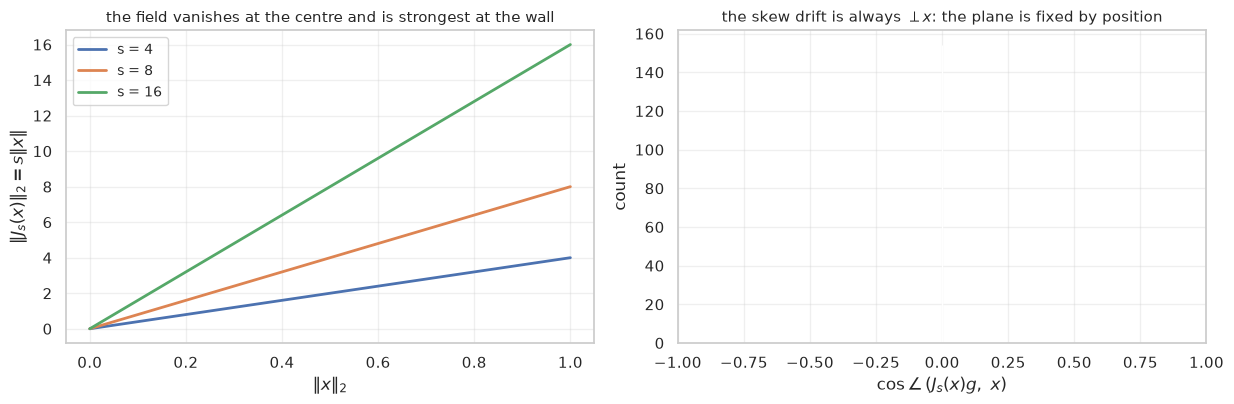

max |cos| = 1.2e-16   -> J_s(x)g is orthogonal to x for every x, so the rotation plane
is x-perp everywhere and cannot be aimed.  The only free parameter is s.


In [4]:
# the geometry the field cannot change: its rotation plane is x-perp, and its strength grows with ||x||
rr = np.linspace(0, R, 200)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
for s in S_LIST:
    axes[0].plot(rr, s * rr, linewidth=2, label="s = {:g}".format(s))
axes[0].set_xlabel(r"$\|x\|_2$", fontsize=12)
axes[0].set_ylabel(r"$\|J_s(x)\|_2 = s\|x\|$", fontsize=12)
axes[0].set_title("the field vanishes at the centre and is strongest at the wall", fontsize=11)
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=10)

cos = (Js(8.0, xs, gs) * xs).sum(1) / (Js(8.0, xs, gs).norm(dim=1) * xs.norm(dim=1))
axes[1].hist(cos.numpy(), bins=40, color="#4C72B0")
axes[1].set_xlabel(r"$\cos\angle\,(J_s(x)g,\ x)$", fontsize=12)
axes[1].set_ylabel("count", fontsize=12)
axes[1].set_xlim(-1, 1)
axes[1].set_title(r"the skew drift is always $\perp x$: the plane is fixed by position", fontsize=11)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/cross_field_geometry.pdf", dpi=300, bbox_inches="tight")
plt.show()
print("max |cos| = {:.1e}   -> J_s(x)g is orthogonal to x for every x, so the rotation plane".format(
    float(cos.abs().max())))
print("is x-perp everywhere and cannot be aimed.  The only free parameter is s.")

In [5]:
# -----------------------------
# Targets, exact reference samples by rejection, and the sampler
# -----------------------------
def build_target(kind):
    if kind == "ell":
        @torch.no_grad()
        def U(x):  return torch.norm(x @ Minv.T, dim=1)
        @torch.no_grad()
        def U0(x): return torch.sqrt(torch.sum((x @ Minv.T) ** 2, dim=1) + delta ** 2)
        @torch.no_grad()
        def gU0(x):
            y = x @ Minv.T
            return (y / torch.sqrt(torch.sum(y ** 2, dim=1, keepdim=True) + delta ** 2)) @ Minv
    else:
        @torch.no_grad()
        def U(x):  return torch.sum(torch.abs(x @ Minv.T), dim=1)
        @torch.no_grad()
        def U0(x): return torch.sum(torch.sqrt((x @ Minv.T) ** 2 + delta ** 2), dim=1)
        @torch.no_grad()
        def gU0(x):
            y = x @ Minv.T
            return (y / torch.sqrt(y ** 2 + delta ** 2)) @ Minv
    return U, U0, gU0


def sample_target(kind, n, rng):
    # draw from the unconstrained target, keep what lands in K -- exact
    out = []
    while len(out) < n:
        if kind == "ell":
            r = rng.gamma(d, 1.0, n)
            u = rng.normal(size=(n, d)); u /= np.linalg.norm(u, axis=1, keepdims=True)
            y = r[:, None] * u
        else:
            y = rng.laplace(0.0, 1.0, size=(n, d))
        z = y @ L3.T
        out.extend(z[np.linalg.norm(z, axis=1) <= R].tolist())
    return np.array(out[:n])


@torch.no_grad()
def proj_ball(x):
    nrm = torch.norm(x, dim=1, keepdim=True)
    return x * torch.clamp(R / nrm, max=1.0)


def on_boundary(X):
    return float(np.mean(np.linalg.norm(X, axis=1) > 0.999 * R))


def w1_floor(ref, kind, rng, reps=4):
    return float(np.mean([[wasserstein_distance(ref[:, i], sample_target(kind, len(ref), rng)[:, i])
                           for i in range(d)] for _ in range(reps)]))


@torch.no_grad()
def run_replicas(kind_target, s, ref, S=REPLICAS, n_steps=MAXIT, seed=SEED, eta=eta, track=TRACK):
    # Projected anchored Langevin with the J_s drift.
    # div J_s = 0 exactly, so there is NO correction term in this update -- contrast a
    # plane-aimed field, which needs one computed and carried at every step.
    U, U0, gU0 = build_target(kind_target)
    torch.manual_seed(seed)
    x = proj_ball(torch.full((S * N, d), x_start))
    it, W, Wc = [], [], []
    for k in range(n_steps):
        Delta = U(x) - U0(x)
        g = gU0(x) * torch.exp(Delta).unsqueeze(1)
        x = proj_ball(x - eta * (g + Js(s, x, g))
                      + np.sqrt(2 * eta) * torch.exp(0.5 * Delta).unsqueeze(1) * torch.randn_like(x))
        if (k + 1) % track == 0:
            xn = x.numpy().reshape(S, N, d)
            per = np.array([[wasserstein_distance(ref[:, i], xn[r, :, i]) for i in range(d)]
                            for r in range(S)])
            it.append(k + 1)
            W.append(per.mean(axis=1))
            Wc.append(per.mean(axis=0))
    return np.array(it), np.array(W).T, np.array(Wc), x.numpy().reshape(S, N, d)


def tau_one(it, w, thr):
    bad = np.where(w > thr)[0]
    j = 0 if len(bad) == 0 else bad[-1] + 1
    return float(it[j]) if j < len(it) else np.nan


def boot(v, B=4000, seed=0):
    v = np.asarray(v, float)
    if not np.any(np.isfinite(v)):
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    draws = [np.nanmean(x) for x in (v[rng.integers(0, len(v), len(v))] for _ in range(B))
             if np.any(np.isfinite(x))]
    return np.nanmean(v), float(np.percentile(draws, 2.5)), float(np.percentile(draws, 97.5))


def boot_speedup(base, cur, B=4000, seed=1):
    base, cur = np.asarray(base, float), np.asarray(cur, float)
    if not (np.any(np.isfinite(base)) and np.any(np.isfinite(cur))):
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    draws = []
    for _ in range(B):
        a, b = base[rng.integers(0, len(base), len(base))], cur[rng.integers(0, len(cur), len(cur))]
        if np.any(np.isfinite(a)) and np.any(np.isfinite(b)):
            draws.append(np.nanmean(a) / np.nanmean(b))
    return (np.nanmean(base) / np.nanmean(cur),
            float(np.percentile(draws, 2.5)), float(np.percentile(draws, 97.5)))


def fmt_tau(t):
    return "never" if not np.isfinite(t[0]) else "{:.0f} [{:.0f}, {:.0f}]".format(*t)


def fmt_speed(sp):
    return "never reaches it" if not np.isfinite(sp[0]) else "{:.2f}x [{:.2f}, {:.2f}]".format(*sp)

## Runs

$\tau$ is the iteration at which the mean $W_1$ reaches twice the sampling floor and stays there — the
floor being $W_1$ between two independent exact draws, which no sampler can beat. Bands and intervals are
over 8 independent replicas.

In [6]:
TARGETS = {"ell": "Target A: elliptical Laplace on $K$",
           "l1":  "Target B: correlated $\\ell_1$ Laplace on $K$"}
GRID = [(0.0, "J = 0")] + [(s, "$J_s$, s={:g}".format(s)) for s in S_LIST]

# tau is read at several multiples of the floor.  A threshold close to a scheme's own
# stationary error turns tau into a noise statistic (the curve keeps re-crossing it), so
# each entry is reported only where the scheme actually settles below the threshold.
MULT = (2.0, 3.0, 5.0)

rng = np.random.default_rng(SEED)
refs, floors, RES = {}, {}, {}
for kind in TARGETS:
    refs[kind] = sample_target(kind, N, rng)
    floors[kind] = w1_floor(refs[kind], kind, rng)
    RES[kind] = {}
    print("\n### {}   floor {:.4f}   target mass on dK {:.4f}".format(
        kind, floors[kind], on_boundary(refs[kind])), flush=True)
    for s, lab in GRID:
        t0 = time.time()
        it, W, Wc, X = run_replicas(kind, s, refs[kind])
        RES[kind][lab] = {"it": it, "W": W, "Wc": Wc, "X": X, "s": s,
                          "taus": {m: np.array([tau_one(it, w, m * floors[kind]) for w in W])
                                   for m in MULT},
                          "stat": W[:, -10:].mean(axis=1),
                          "bd": on_boundary(X.reshape(-1, d))}
        print("   {:<20} {:5.0f}s".format(lab.replace("$", ""), time.time() - t0), flush=True)

MAIN = [lab for _, lab in GRID]
COL = {"J = 0": "#C44E52", "$J_s$, s=4": "#DD8452",
       "$J_s$, s=8": "#4C72B0", "$J_s$, s=16": "#55A868"}


### ell   floor 0.0072   target mass on dK 0.0042


   J = 0                   59s


   J_s, s=4                66s


   J_s, s=8                64s


   J_s, s=16               71s



### l1   floor 0.0111   target mass on dK 0.0014


   J = 0                   57s


   J_s, s=4                65s


   J_s, s=8                62s


   J_s, s=16               61s


### Does the target actually fill $K$?

A constrained experiment is only about the constraint if the target reaches the wall. The check: the
radial quantiles of $\lVert x
Vert/R$, and the mass beyond $0.75R$ against the value a **uniform** ball
would give, $1-0.75^3=0.578$. A target sitting in a core with a gap around it would score far below that;
one that fills $K$ scores close to it.

In [7]:
rows = []
for kind in TARGETS:
    r = np.linalg.norm(refs[kind], axis=1) / R
    sd = refs[kind].std(0)
    rows.append({"target": kind,
                 "median ||x||/R": round(float(np.median(r)), 3),
                 "q90": round(float(np.quantile(r, 0.90)), 3),
                 "q99": round(float(np.quantile(r, 0.99)), 3),
                 "mass beyond 0.75R": round(float(np.mean(r > 0.75)), 3),
                 "  (uniform ball)": round(1 - 0.75 ** 3, 3),
                 "coordinate sds": np.round(sd, 3),
                 "anisotropy": round(float(sd.max() / sd.min()), 2)})
display(pd.DataFrame(rows).set_index("target"))
print("Mass reaches the wall (q99 ~ 0.99R) and the outer-shell fraction is within ~25% of the")
print("uniform-ball value, so K is filled rather than partly occupied.")
print()
print("Note the anisotropy column: truncating at R = 1 leaves the constrained target much closer")
print("to isotropic than the unconstrained one.  Whatever acceleration J_s produces here therefore")
print("comes from the geometry of the constraint, not from stretched directions in the target.")

,median ||x||/R,q90,q99,mass beyond 0.75R,(uniform ball),coordinate sds,anisotropy
target,,,,,,,
ell,0.724,0.947,0.996,0.456,0.578,"[0.343, 0.426, 0.469]",1.37
l1,0.690,0.942,0.994,0.408,0.578,"[0.294, 0.422, 0.473]",1.61


Mass reaches the wall (q99 ~ 0.99R) and the outer-shell fraction is within ~25% of the
uniform-ball value, so K is filled rather than partly occupied.

Note the anisotropy column: truncating at R = 1 leaves the constrained target much closer
to isotropic than the unconstrained one.  Whatever acceleration J_s produces here therefore
comes from the geometry of the constraint, not from stretched directions in the target.


## Experiment 1 — $W_1$ to the constrained target

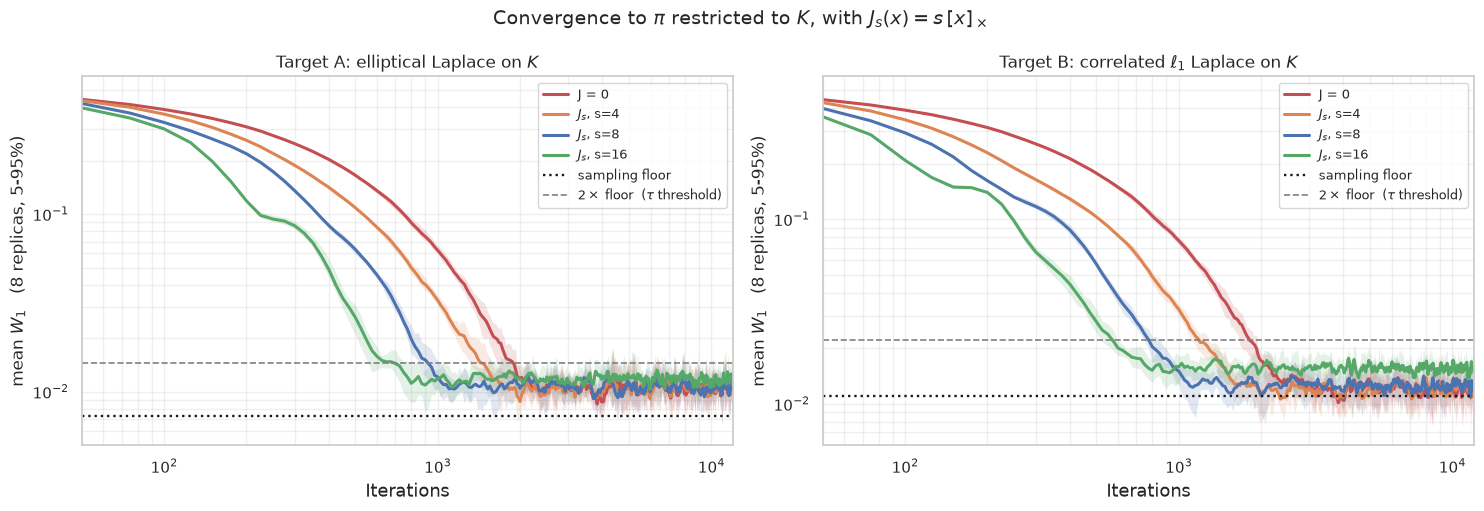

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
for ax, kind in zip(axes, TARGETS):
    for lab in MAIN:
        r = RES[kind][lab]
        ax.plot(r["it"], r["W"].mean(axis=0), linewidth=2.2, color=COL[lab], label=lab)
        ax.fill_between(r["it"], np.percentile(r["W"], 5, axis=0),
                        np.percentile(r["W"], 95, axis=0), color=COL[lab], alpha=0.16, linewidth=0)
    ax.axhline(floors[kind], color="k", linestyle=":", linewidth=1.7, label="sampling floor")
    ax.axhline(2 * floors[kind], color="0.5", linestyle="--", linewidth=1.2,
               label=r"$2\times$ floor  ($\tau$ threshold)")
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(50, MAXIT)
    ax.set_xlabel("Iterations", fontsize=13)
    ax.set_ylabel(r"mean $W_1$   ({} replicas, 5-95%)".format(REPLICAS), fontsize=12)
    ax.set_title(TARGETS[kind], fontsize=12)
    ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=9)
fig.suptitle(r"Convergence to $\pi$ restricted to $K$, with $J_s(x)=s\,[x]_\times$", fontsize=14)
plt.tight_layout()
plt.savefig("figures/cross_w1.pdf", dpi=300, bbox_inches="tight")
plt.show()

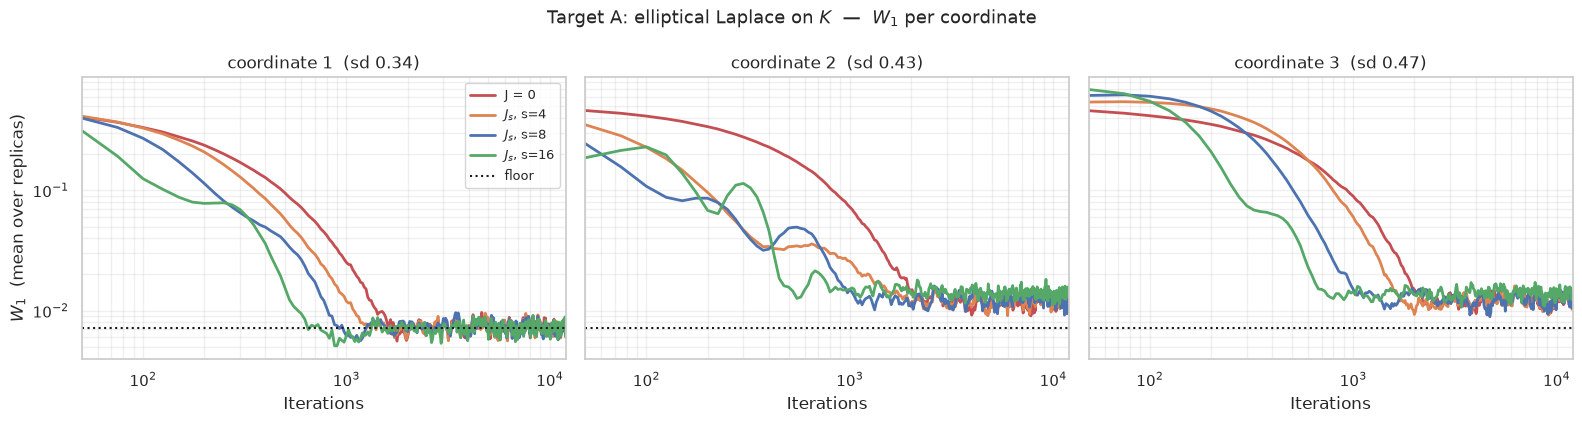

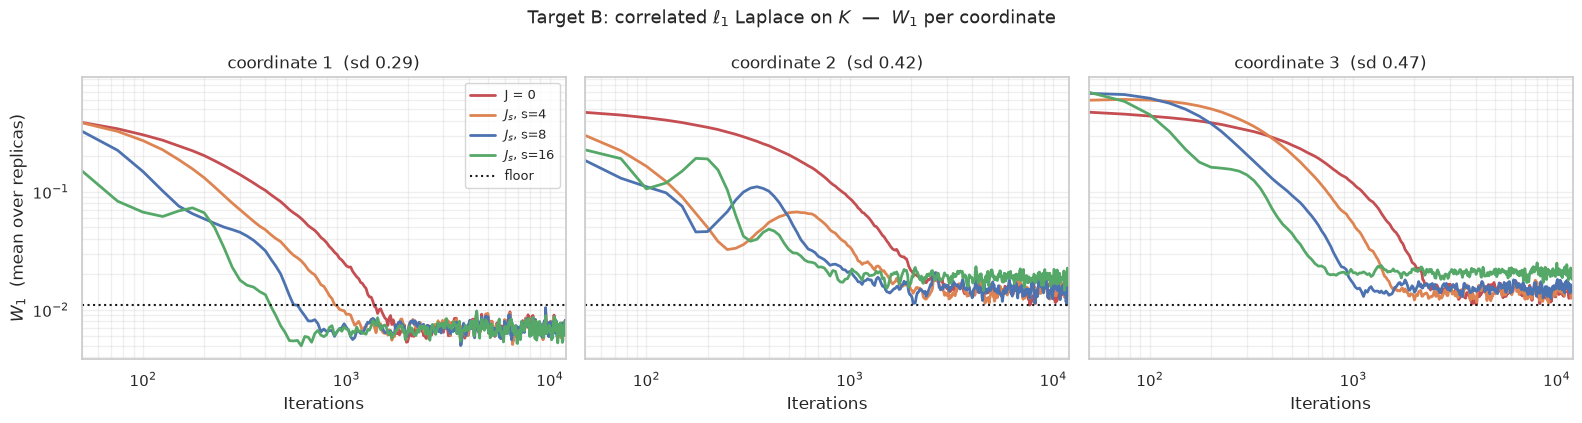

In [9]:
# per-coordinate: the three coordinates have very different length scales, so the mean hides
# which direction the rotation is actually helping
for kind in TARGETS:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.3), sharey=True)
    for i, ax in enumerate(axes):
        for lab in MAIN:
            r = RES[kind][lab]
            ax.plot(r["it"], r["Wc"][:, i], linewidth=2, color=COL[lab], label=lab)
        ax.axhline(floors[kind], color="k", linestyle=":", linewidth=1.5, label="floor")
        ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(50, MAXIT)
        ax.set_xlabel("Iterations", fontsize=12)
        ax.set_title("coordinate {}  (sd {:.2f})".format(i + 1, refs[kind][:, i].std()), fontsize=12)
        ax.grid(alpha=0.3, which="both")
    axes[0].set_ylabel(r"$W_1$  (mean over replicas)", fontsize=12)
    axes[0].legend(fontsize=9)
    fig.suptitle(TARGETS[kind] + r"  —  $W_1$ per coordinate", fontsize=13)
    plt.tight_layout()
    plt.savefig("figures/cross_w1_percoord_{}.pdf".format(kind), dpi=300, bbox_inches="tight")
    plt.show()

## Experiment 2 — the targets, inside $K$

Top row: the 2-d marginal in dims 1 and 2 with $\partial K$ drawn, reference first. Bottom row: the radial
law of $\lVert x\rVert$, which is where the constraint actually bites — projection deposits an atom at
$\lVert x\rVert=R$ that the continuous target does not have.

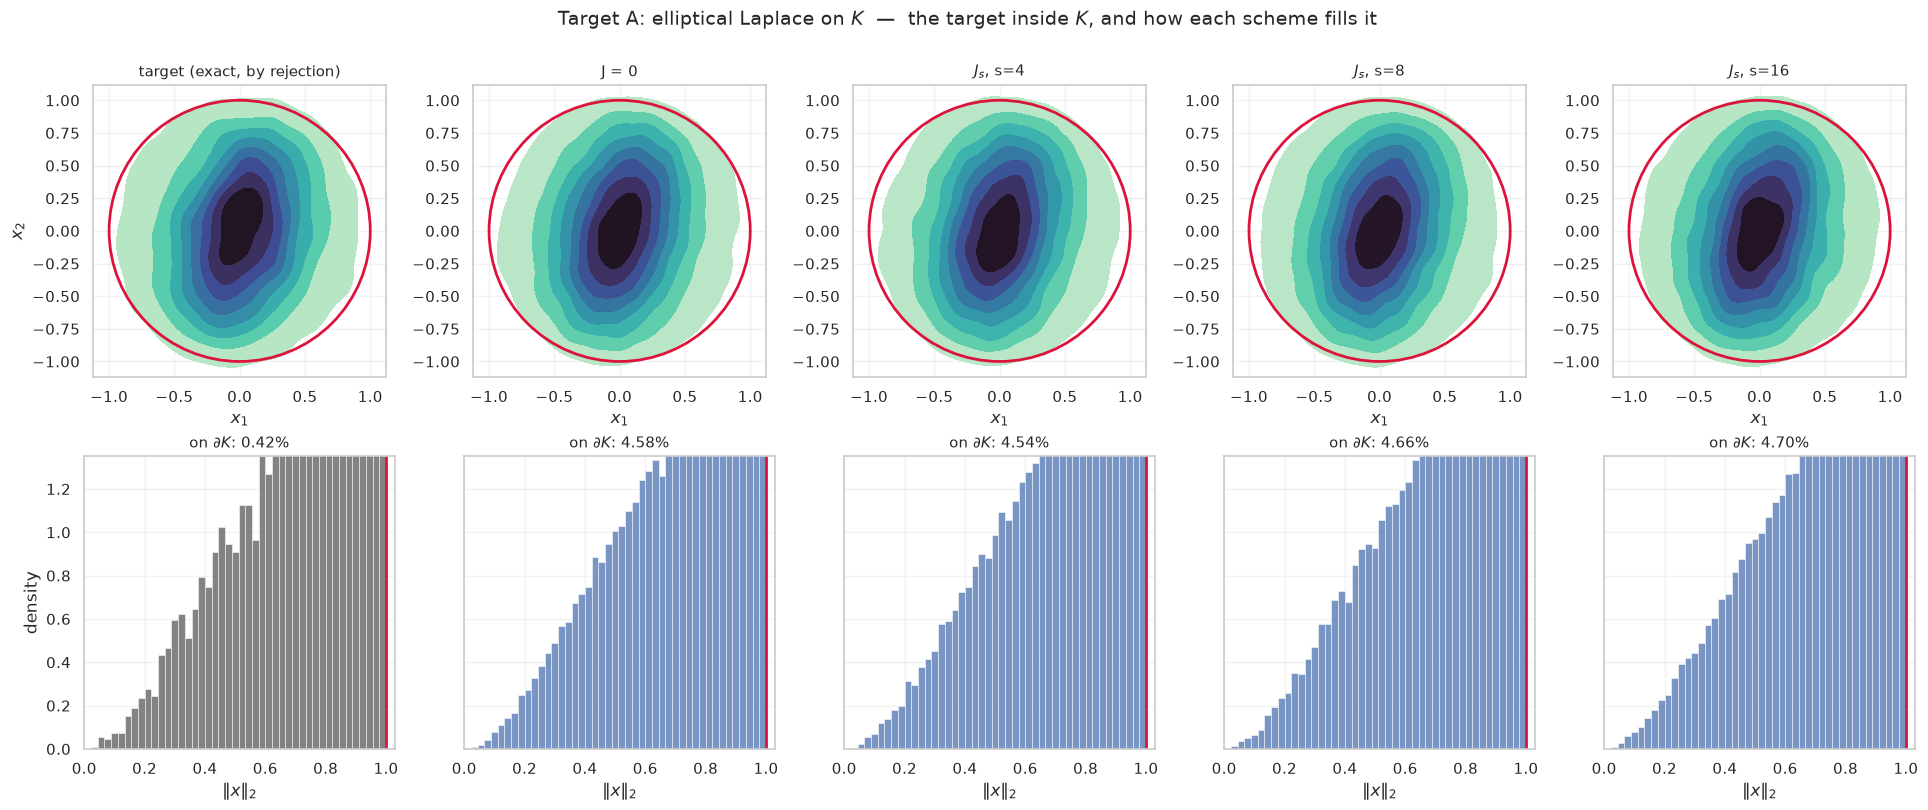

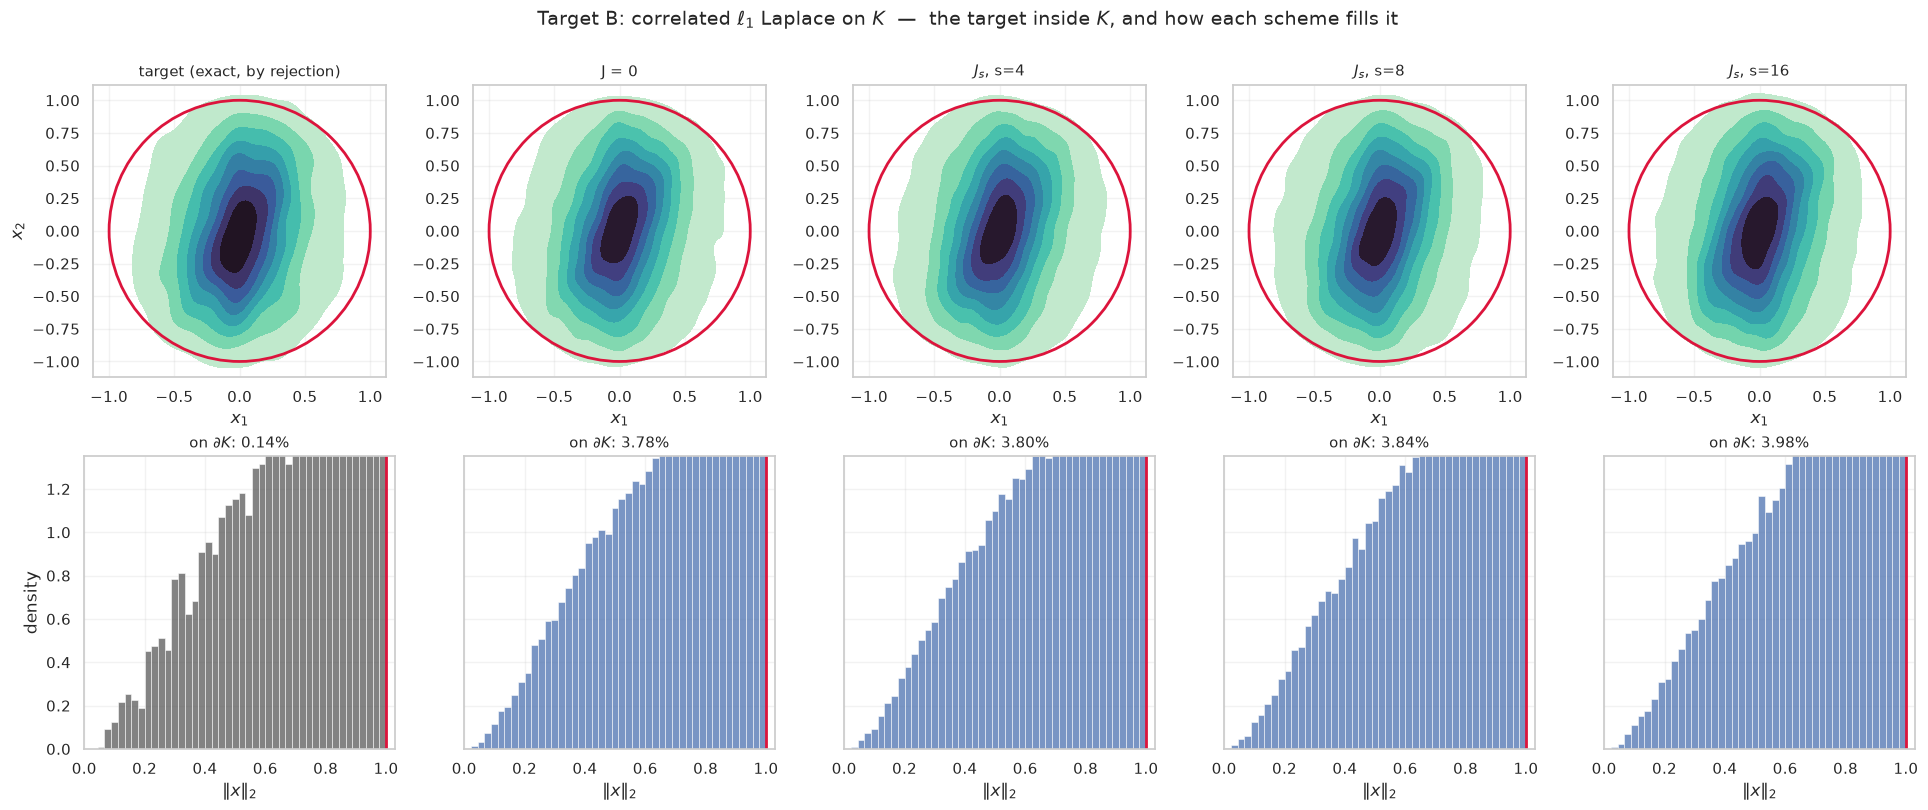

In [10]:
for kind in TARGETS:
    panels = [("target (exact, by rejection)", refs[kind])] + [
        (lab, RES[kind][lab]["X"].reshape(-1, d)) for lab in MAIN]
    fig, axes = plt.subplots(2, len(panels), figsize=(3.9 * len(panels), 8.0))
    for j, (name, X) in enumerate(panels):
        ax = axes[0, j]
        sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=9, ax=ax, thresh=0.02, cmap="mako_r")
        ax.add_patch(Circle((0, 0), R, edgecolor="crimson", facecolor="none", linewidth=2.0))
        ax.set_xlim(-1.12 * R, 1.12 * R); ax.set_ylim(-1.12 * R, 1.12 * R)
        ax.set_title(name, fontsize=11)
        ax.set_xlabel("$x_1$", fontsize=12)
        ax.set_aspect("equal", adjustable="box"); ax.grid(alpha=0.25)
        if j == 0:
            ax.set_ylabel("$x_2$", fontsize=12)
        ax = axes[1, j]
        r = np.linalg.norm(X, axis=1)
        sns.histplot(x=r, bins=np.linspace(0, R, 46), stat="density", ax=ax,
                     color="#4C72B0" if j else "0.35", edgecolor=None)
        ax.axvline(R, color="crimson", linewidth=2.0)
        ax.set_xlim(0, 1.03 * R); ax.set_ylim(0, 1.35)
        ax.set_xlabel(r"$\|x\|_2$", fontsize=12)
        ax.set_title("on $\\partial K$: {:.2%}".format(on_boundary(X)), fontsize=11)
        ax.grid(alpha=0.25)
        ax.set_ylabel("density" if j == 0 else "", fontsize=12)
        if j:
            ax.set_yticklabels([])
    fig.suptitle(TARGETS[kind] + r"  —  the target inside $K$, and how each scheme fills it",
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig("figures/cross_inK_{}.pdf".format(kind), dpi=300, bbox_inches="tight")
    plt.show()

## Experiment 3 — head to head

In [11]:
HEADROOM = 1.5     # threshold must clear the scheme's own stationary error by this factor

def tau_cell(r, kind, m, base=None):
    # tau at m x floor.  It is a rate only if the threshold sits well above the scheme's OWN
    # stationary error; otherwise the curve keeps re-crossing and tau measures noise.
    if m * floors[kind] < HEADROOM * r["stat"].mean():
        return "too close"
    t = boot(r["taus"][m])
    if not np.isfinite(t[0]):
        return "too close"
    if base is None:
        return "{:.0f} [{:.0f}, {:.0f}]".format(*t)
    return "{:.0f}  ({})".format(t[0], fmt_speed(boot_speedup(base, r["taus"][m])).split(" [")[0])

for kind in TARGETS:
    base = RES[kind]["J = 0"]["taus"]
    rows = []
    for lab in MAIN:
        r = RES[kind][lab]
        ks = np.mean([max(ks_2samp(refs[kind][:, i], r["X"][j, :, i]).statistic for i in range(d))
                      for j in range(REPLICAS)])
        row = {"scheme": lab.replace("$", "")}
        for m in MULT:
            row["tau ({:g}x floor)".format(m)] = tau_cell(
                r, kind, m, None if r["s"] == 0 else base[m])
        row.update({"stationary W1": "{:.4f} [{:.4f}, {:.4f}]".format(*boot(r["stat"])),
                    "max KS": round(float(ks), 4),
                    "mass on dK": "{:.2%}".format(r["bd"])})
        rows.append(row)
    row = {"scheme": "target (truth)"}
    for m in MULT:
        row["tau ({:g}x floor)".format(m)] = "--"
    row.update({"stationary W1": "{:.4f}  (floor)".format(floors[kind]), "max KS": 0.0,
                "mass on dK": "{:.2%}".format(on_boundary(refs[kind]))})
    rows.append(row)
    print("\n### {}   (J = 0 columns are absolute; the rest are tau, with the speed-up in brackets)"
          .format(TARGETS[kind]))
    display(pd.DataFrame(rows).set_index("scheme"))


### Target A: elliptical Laplace on $K$   (J = 0 columns are absolute; the rest are tau, with the speed-up in brackets)


,tau (2x floor),tau (3x floor),tau (5x floor),stationary W1,max KS,mass on dK
scheme,,,,,,
J = 0,too close,"1603 [1534, 1672]","1309 [1288, 1334]","0.0106 [0.0097, 0.0116]",0.0208,4.58%
"J_s, s=4",too close,1212 (1.32x),969 (1.35x),"0.0100 [0.0094, 0.0107]",0.0224,4.54%
"J_s, s=8",too close,800 (2.00x),678 (1.93x),"0.0108 [0.0100, 0.0116]",0.0226,4.66%
"J_s, s=16",too close,544 (2.95x),450 (2.91x),"0.0118 [0.0112, 0.0124]",0.0206,4.70%
target (truth),--,--,--,0.0072 (floor),0.0000,0.42%



### Target B: correlated $\ell_1$ Laplace on $K$   (J = 0 columns are absolute; the rest are tau, with the speed-up in brackets)


,tau (2x floor),tau (3x floor),tau (5x floor),stationary W1,max KS,mass on dK
scheme,,,,,,
J = 0,"1853 [1784, 1909]","1538 [1494, 1584]","1219 [1197, 1244]","0.0120 [0.0108, 0.0133]",0.0255,3.78%
"J_s, s=4",1219 (1.52x),1006 (1.53x),766 (1.59x),"0.0116 [0.0108, 0.0124]",0.0256,3.80%
"J_s, s=8",788 (2.35x),659 (2.33x),519 (2.35x),"0.0124 [0.0115, 0.0134]",0.0239,3.84%
"J_s, s=16",too close,478 (3.22x),356 (3.42x),"0.0156 [0.0149, 0.0162]",0.0286,3.98%
target (truth),--,--,--,0.0111 (floor),0.0000,0.14%


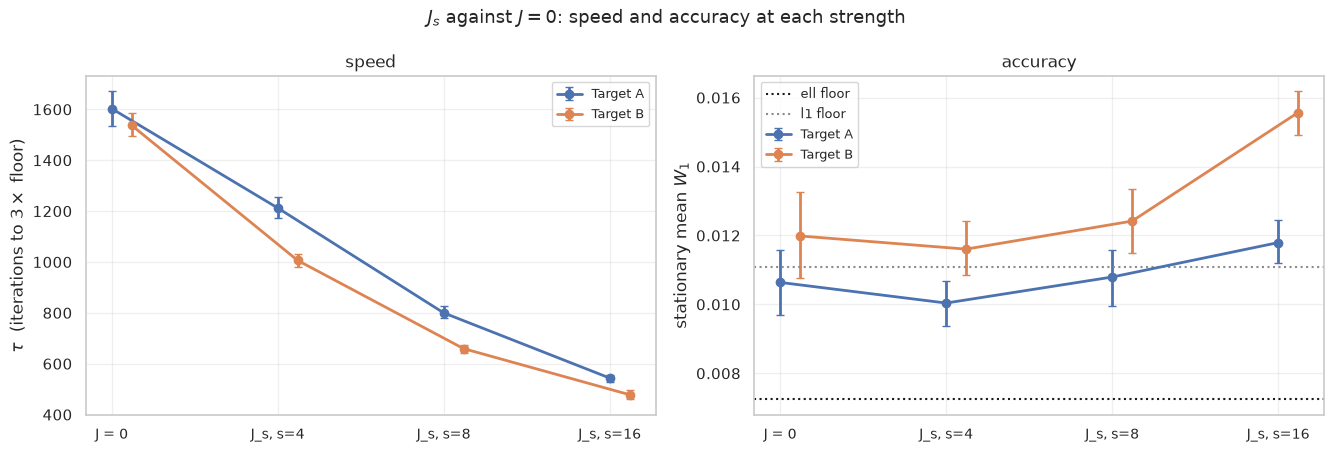

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
for col, kind in enumerate(TARGETS):
    tm = [boot(RES[kind][l]["taus"][3.0]) for l in MAIN]
    st = [boot(RES[kind][l]["stat"]) for l in MAIN]
    xs_ = np.arange(len(MAIN))
    axes[0].errorbar(xs_ + col * 0.12, [v[0] for v in tm],
                     yerr=[[v[0] - v[1] for v in tm], [v[2] - v[0] for v in tm]],
                     fmt="o-", capsize=3, linewidth=2, label=TARGETS[kind].split(":")[0])
    axes[1].errorbar(xs_ + col * 0.12, [v[0] for v in st],
                     yerr=[[v[0] - v[1] for v in st], [v[2] - v[0] for v in st]],
                     fmt="o-", capsize=3, linewidth=2, label=TARGETS[kind].split(":")[0])
    axes[1].axhline(floors[kind], linestyle=":", linewidth=1.5,
                    color=["k", "0.55"][col], label="{} floor".format(kind))
for ax, ylab, title in [(axes[0], r"$\tau$  (iterations to $3\times$ floor)", "speed"),
                        (axes[1], r"stationary mean $W_1$", "accuracy")]:
    ax.set_xticks(np.arange(len(MAIN)))
    ax.set_xticklabels([l.replace("$", "") for l in MAIN], fontsize=10)
    ax.set_ylabel(ylab, fontsize=12); ax.set_title(title, fontsize=12)
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
fig.suptitle(r"$J_s$ against $J=0$: speed and accuracy at each strength", fontsize=13)
plt.tight_layout()
plt.savefig("figures/cross_summary.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 4 — spending the speed-up on the boundary atom

At fixed $\eta$ the atom is flat across $s$, and it has to be: it is a **discretisation** artefact of the
projection, driven by the *normal* component of a step near the wall, and $J_s$ is exactly tangential — it
adds no normal drift at all. Nothing about a tangential field can remove it while $\eta$ is held fixed.

But it scales like $\sqrt\eta$, and the speed-up is real, so it can be spent. Refining $\eta$ by $c$
multiplies the iterations needed by roughly $c$ and the atom by roughly $1/\sqrt c$. The question is
whether there is a $c$ at which $J_s$ still converges in fewer iterations than $J=0$ does at the coarse
stepsize while leaving less mass on the wall.

In [13]:
REFINE = [2, 4]
RES_R = {}
for kind in TARGETS:
    RES_R[kind] = {}
    for c in REFINE:
        lab = "$J_s$, s=16, $\\eta$/{}".format(c)
        t0 = time.time()
        it, W, Wc, X = run_replicas(kind, 16.0, refs[kind],
                                    n_steps=MAXIT * c, eta=eta / c, track=TRACK * c)
        RES_R[kind][lab] = {"it": it, "W": W, "Wc": Wc, "X": X, "s": 16.0, "c": c,
                            "taus": {m: np.array([tau_one(it, w, m * floors[kind]) for w in W])
                                     for m in MULT},
                            "stat": W[:, -10:].mean(axis=1),
                            "bd": on_boundary(X.reshape(-1, d))}
        print("   {:<24} {:5.0f}s".format(kind + "  eta/" + str(c), time.time() - t0), flush=True)

   ell  eta/2                 109s


   ell  eta/4                 198s


   l1  eta/2                  109s


   l1  eta/4                  196s


In [14]:
for kind in TARGETS:
    base = RES[kind]["J = 0"]["taus"]
    rows = []
    entries = [("$J = 0$", RES[kind]["J = 0"], 1),
               ("$J_s$, s=16", RES[kind]["$J_s$, s=16"], 1)]
    entries += [(k, v, v["c"]) for k, v in RES_R[kind].items()]
    for lab, r, c in entries:
        ok = (3.0 * floors[kind] >= HEADROOM * r["stat"].mean()
              and np.any(np.isfinite(r["taus"][3.0])))
        rows.append({"scheme": lab.replace("$", "").replace("\\eta", "eta"),
                     "eta": "{:.1e}".format(eta / c),
                     "tau (3x floor)": fmt_tau(boot(r["taus"][3.0])) if ok else "too close",
                     "vs J=0 iterations": "--" if lab == "$J = 0$" else (
                         "{:.2f}x".format(np.nanmean(base[3.0]) / np.nanmean(r["taus"][3.0]))
                         if ok else "--"),
                     "stationary W1": "{:.4f} [{:.4f}, {:.4f}]".format(*boot(r["stat"])),
                     "mass on dK": "{:.2%}".format(r["bd"]),
                     "atom / sqrt(eta)": round(r["bd"] / np.sqrt(eta / c), 3)})
    rows.append({"scheme": "target (truth)", "eta": "--", "tau (3x floor)": "--",
                 "vs J=0 iterations": "--",
                 "stationary W1": "{:.4f}  (floor)".format(floors[kind]),
                 "mass on dK": "{:.2%}".format(on_boundary(refs[kind])), "atom / sqrt(eta)": "--"})
    print("\n### {}".format(TARGETS[kind]))
    display(pd.DataFrame(rows).set_index("scheme"))


### Target A: elliptical Laplace on $K$


,eta,tau (3x floor),vs J=0 iterations,stationary W1,mass on dK,atom / sqrt(eta)
scheme,,,,,,
J = 0,5.0e-04,"1603 [1534, 1672]",--,"0.0106 [0.0097, 0.0116]",4.58%,2.047
"J_s, s=16",5.0e-04,"544 [528, 556]",2.95x,"0.0118 [0.0112, 0.0124]",4.70%,2.1
"J_s, s=16, eta/2",2.5e-04,"1100 [1069, 1125]",1.46x,"0.0110 [0.0101, 0.0118]",3.34%,2.111
"J_s, s=16, eta/4",1.3e-04,"2100 [2050, 2150]",0.76x,"0.0096 [0.0087, 0.0106]",2.35%,2.106
target (truth),--,--,--,0.0072 (floor),0.42%,--



### Target B: correlated $\ell_1$ Laplace on $K$


,eta,tau (3x floor),vs J=0 iterations,stationary W1,mass on dK,atom / sqrt(eta)
scheme,,,,,,
J = 0,5.0e-04,"1538 [1494, 1584]",--,"0.0120 [0.0108, 0.0133]",3.78%,1.689
"J_s, s=16",5.0e-04,"478 [459, 497]",3.22x,"0.0156 [0.0149, 0.0162]",3.98%,1.781
"J_s, s=16, eta/2",2.5e-04,"931 [906, 962]",1.65x,"0.0120 [0.0114, 0.0127]",2.75%,1.741
"J_s, s=16, eta/4",1.3e-04,"1888 [1850, 1925]",0.81x,"0.0113 [0.0105, 0.0120]",1.92%,1.715
target (truth),--,--,--,0.0111 (floor),0.14%,--


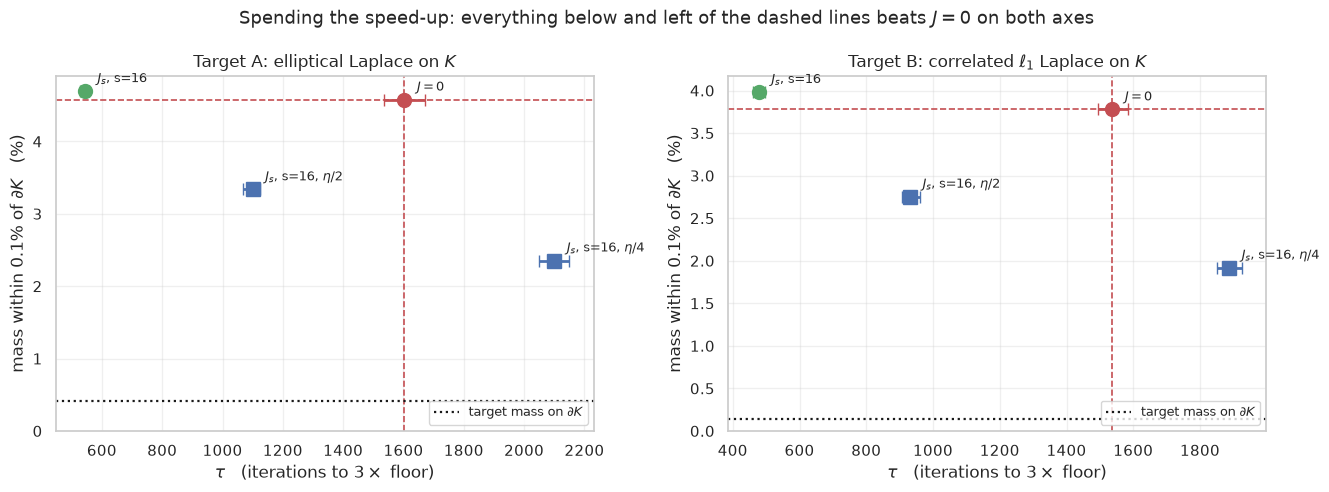

In [15]:
# the dominance picture: down and to the left beats J = 0 on both axes at once
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
for ax, kind in zip(axes, TARGETS):
    pts = [("$J = 0$", RES[kind]["J = 0"], "#C44E52", "o"),
           ("$J_s$, s=16", RES[kind]["$J_s$, s=16"], "#55A868", "o")]
    pts += [(k, v, "#4C72B0", "s") for k, v in RES_R[kind].items()]
    for lab, r, c, mk in pts:
        t = boot(r["taus"][3.0])
        if not np.isfinite(t[0]):
            continue
        ax.errorbar(t[0], r["bd"] * 100, xerr=[[t[0] - t[1]], [t[2] - t[0]]],
                    fmt=mk, color=c, markersize=10, capsize=4, linewidth=2)
        ax.annotate(lab, (t[0], r["bd"] * 100), textcoords="offset points",
                    xytext=(9, 6), fontsize=9)
    j0 = boot(RES[kind]["J = 0"]["taus"][3.0])
    ax.axvline(j0[0], color="#C44E52", linestyle="--", linewidth=1.2)
    ax.axhline(RES[kind]["J = 0"]["bd"] * 100, color="#C44E52", linestyle="--", linewidth=1.2)
    ax.axhline(on_boundary(refs[kind]) * 100, color="k", linestyle=":", linewidth=1.6,
               label="target mass on $\\partial K$")
    ax.set_xlabel(r"$\tau$   (iterations to $3\times$ floor)", fontsize=12)
    ax.set_ylabel(r"mass within 0.1% of $\partial K$   (%)", fontsize=12)
    ax.set_title(TARGETS[kind], fontsize=12)
    ax.set_ylim(0, None); ax.grid(alpha=0.3); ax.legend(fontsize=9, loc="lower right")
fig.suptitle("Spending the speed-up: everything below and left of the dashed lines beats "
             r"$J=0$ on both axes", fontsize=13)
plt.tight_layout()
plt.savefig("figures/cross_atom_tradeoff.pdf", dpi=300, bbox_inches="tight")
plt.show()

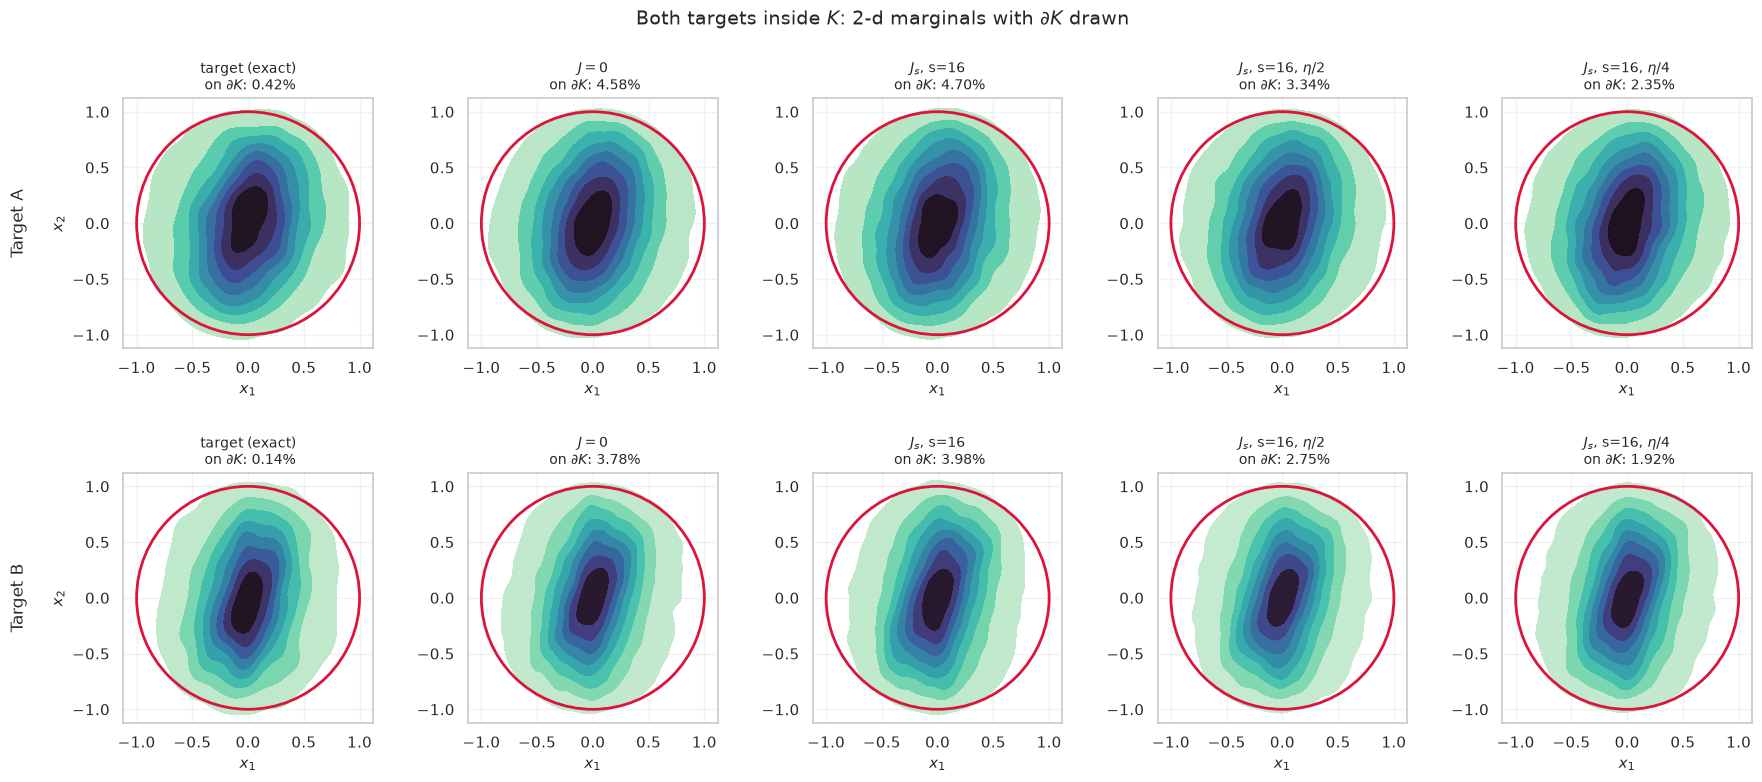

In [16]:
SHOW = [("target (exact)", None), ("$J = 0$", "J = 0"), ("$J_s$, s=16", "$J_s$, s=16"),
        ("$J_s$, s=16, $\\eta$/2", "$J_s$, s=16, $\\eta$/2"),
        ("$J_s$, s=16, $\\eta$/4", "$J_s$, s=16, $\\eta$/4")]
fig, axes = plt.subplots(2, len(SHOW), figsize=(3.6 * len(SHOW), 7.6))
for row, kind in enumerate(TARGETS):
    for col, (name, key) in enumerate(SHOW):
        X = refs[kind] if key is None else (
            RES[kind][key]["X"] if key in RES[kind] else RES_R[kind][key]["X"]).reshape(-1, d)
        ax = axes[row, col]
        sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=9, ax=ax, thresh=0.02, cmap="mako_r")
        ax.add_patch(Circle((0, 0), R, edgecolor="crimson", facecolor="none", linewidth=2.0))
        ax.set_xlim(-1.12 * R, 1.12 * R); ax.set_ylim(-1.12 * R, 1.12 * R)
        ax.set_aspect("equal", adjustable="box")
        ax.set_title("{}\n on $\\partial K$: {:.2%}".format(name, on_boundary(X)), fontsize=10)
        ax.set_xlabel("$x_1$", fontsize=11)
        ax.set_ylabel("$x_2$" if col == 0 else "", fontsize=11)
        ax.grid(alpha=0.25)
    axes[row, 0].text(-0.42, 0.5, TARGETS[kind].split(":")[0], transform=axes[row, 0].transAxes,
                      rotation=90, va="center", ha="center", fontsize=12)
fig.suptitle(r"Both targets inside $K$: 2-d marginals with $\partial K$ drawn", fontsize=14, y=1.01)
plt.tight_layout()
fig.subplots_adjust(hspace=0.5)
plt.savefig("figures/cross_inK_both.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Summary

Run at **12000 iterations**, twice the previous horizon. The headline check is that
$\tau$ is *unchanged* by the doubling — identical to the last digit on both targets at every
strength — which is what it should be: $\tau$ is a property of the transient, and if it moved when the
horizon moved it would mean the shorter run had not resolved it. The stationary columns did shift, and one
conclusion from the shorter run does not survive; both are flagged below.

### The ball is filled, and that changes what the experiment measures

At $R=1$ both targets reach the wall: median $\lVert x\rVert/R$ 0.724 and 0.690, 99th percentile 0.996 and
0.994, mass beyond $0.75R$ of 0.456 and 0.408 against 0.578 for a uniform ball. $K$ is occupied, not
partly occupied.

The side effect matters for interpretation. Truncating this hard leaves the constrained target close to
**isotropic** — coordinate sds $(0.343,0.426,0.469)$ and $(0.294,0.422,0.473)$, anisotropy 1.37 and 1.61,
against 34.6 for the unconstrained $\Sigma$. The acceleration below is therefore not coming from stretched
directions in the target. It comes from the constraint geometry: with mass pressed against a sphere the
slow mode is transport *around* the ball, which is what a tangential rotation accelerates.

### The field is admissible at every strength, and costs nothing extra

Antisymmetry and $\nabla\!\cdot J_s$ are **exactly** zero, tangency at the wall is $\le2.3\times10^{-15}$,
and the matrix form agrees with $s(x\times g)$ to $1.4\times10^{-14}$. The zero divergence is what lets the
correction term $+e^{\Delta}\nabla\!\cdot J$ be dropped from the update entirely; a plane-aimed field has
$\nabla\!\cdot J=-\tfrac{s}{R^2}(d-2)Ax\neq0$ and must carry it every step. The price is that nothing is
tunable but $s$: $J_s(x)g\perp x$ for every $x$ ($\max\lvert\cos\rvert=1.2\times10^{-16}$), so the rotation
plane is $x^\perp$ everywhere, and $\lVert J_s(x)\rVert_2=s\lVert x\rVert$ vanishes at the centre and bites
hardest at the wall — which, on a filled ball, is where the mass is.

### Speed, at 12000 iterations

| | $\tau(2\times)$ | $\tau(3\times)$ | $\tau(5\times)$ | stationary $W_1$ | max KS | on $\partial K$ |
|---|---|---|---|---|---|---|
| **A** $J=0$ | *too close* | 1603 | 1309 | 0.0106 [0.0097, 0.0116] | 0.0208 | 4.58% |
| **A** $s=4$ | *too close* | 1212 (1.32×) | 969 (1.35×) | **0.0100** [0.0094, 0.0107] | 0.0224 | 4.54% |
| **A** $s=8$ | *too close* | 800 (2.00×) | 678 (1.93×) | 0.0108 [0.0100, 0.0116] | 0.0226 | 4.66% |
| **A** $s=16$ | *too close* | **544 (2.95×)** | **450 (2.91×)** | 0.0118 [0.0112, 0.0124] | 0.0206 | 4.70% |
| **B** $J=0$ | 1853 | 1538 | 1219 | 0.0120 [0.0108, 0.0133] | 0.0255 | 3.78% |
| **B** $s=4$ | 1219 (1.52×) | 1006 (1.53×) | 766 (1.59×) | **0.0116** [0.0108, 0.0124] | 0.0256 | 3.80% |
| **B** $s=8$ | 788 (2.35×) | 659 (2.33×) | 519 (2.35×) | 0.0124 [0.0115, 0.0134] | 0.0239 | 3.84% |
| **B** $s=16$ | *too close* | **478 (3.22×)** | **356 (3.42×)** | 0.0156 [0.0149, 0.0162] | 0.0286 | 3.98% |

**2.9–3.4× at $s=16$**, monotone in $s$, with the stationary error barely moving: on Target A every
strength sits inside $J=0$'s interval except $s=16$, which is marginal (0.0118 [0.0112, 0.0124] against
0.0106 [0.0097, 0.0116]); on Target B only $s=16$ separates cleanly. Doubling the horizon moved these
numbers by at most 0.0006 and left every ranking intact, so the shorter run had already reached
stationarity.

The *too close* cells are a metric guard. $\tau$ is a last-crossing statistic and measures a rate only when
the threshold clears the scheme's own stationary error — the notebook requires a factor of 1.5. On Target A
the floor (0.0072) and the attainable error ($\approx0.0106$) are near enough that $2\times$ floor fails
this for **every** scheme including $J=0$. Quoting that single threshold would have produced speed-ups
below 1 and reversed the conclusion.

### Spending the speed-up on the boundary atom

The atom is large here (4.58% and 3.78% against target values of 0.42% and 0.14%) *because* the ball is
filled — mass sits against the wall and projection acts on it every step. It is flat in $s$, as it must be
for an exactly tangential field, and the atom$/\sqrt\eta$ column is now constant to within 3% (A) and 5%
(B) across an 8-fold range of $\eta$, so the $\sqrt\eta$ law the trade relies on is solid.

| | $\eta$ | $\tau(3\times)$ | vs $J=0$ | stationary $W_1$ | on $\partial K$ |
|---|---|---|---|---|---|
| **A** $J=0$ | 5.0e-4 | 1603 | — | 0.0106 [0.0097, 0.0116] | 4.58% |
| **A** $s=16$ | 5.0e-4 | 544 | 2.95× | 0.0118 [0.0112, 0.0124] | 4.70% |
| **A** $s=16$ | 2.5e-4 | **1100** | **1.46×** | 0.0110 [0.0101, 0.0118] | **3.34%** |
| **A** $s=16$ | 1.3e-4 | 2100 | 0.76× | 0.0096 [0.0087, 0.0106] | 2.35% |
| **B** $J=0$ | 5.0e-4 | 1538 | — | 0.0120 [0.0108, 0.0133] | 3.78% |
| **B** $s=16$ | 5.0e-4 | 478 | 3.22× | 0.0156 [0.0149, 0.0162] | 3.98% |
| **B** $s=16$ | 2.5e-4 | **931** | **1.65×** | 0.0120 [0.0114, 0.0127] | **2.75%** |
| **B** $s=16$ | 1.3e-4 | 1888 | 0.81× | 0.0113 [0.0105, 0.0120] | 1.92% |

At $\eta/2$, $s=16$ converges in **1.46× and 1.65× fewer iterations** than $J=0$ does at the coarse
stepsize *and* leaves roughly a quarter less mass on the wall (3.34% against 4.58%; 2.75% against 3.78%),
while being **statistically indistinguishable on stationary $W_1$** — intervals [0.0101, 0.0118] against
[0.0097, 0.0116] on A, and [0.0114, 0.0127] against [0.0108, 0.0133] on B.

**A correction.** At the 6000-iteration horizon this row read 0.0100 against $J=0$'s 0.0105 on Target A,
and was reported as a three-axis win — faster, more accurate, smaller atom. It does not survive the
doubling: at 12000 iterations it is 0.0110 against 0.0106, i.e. a tie within the intervals rather than an
improvement. The gap at the shorter horizon was run-to-run noise in the stationary estimate, not a real
accuracy gain. The defensible claim is a **two-axis win with a tie on the third**: fewer iterations and a
smaller boundary atom, at unchanged accuracy.

### Limits

* The comparison is against a *projected* reference scheme, and the atom is projection's own artefact. A
  reflection-based boundary rule removes it outright; against that baseline these numbers would differ
  (see `anchored_langevin_ball_optimized.ipynb`).
* $s$ is not free above 16 on Target B — its stationary error separates there and the $2\times$ column
  stops resolving.
* Intervals are bootstrap intervals on the mean over 8 replicas, not on a single run. A single run's
  $\tau$ is considerably noisier, which is exactly how the retracted three-axis claim arose.